In [1]:
import pandas as pd
import numpy as np

In [2]:
# Dataset
# Read in the data
df = pd.read_csv('../dataset/tweet_data/tweet_data.csv')

In [3]:
df.sample(10)

,textID,tweet_text,sentiment
3610,1961745324,i am so stressed and sad about pugsly missing....,negative
6402,1964057521,Boooo Animal collective is already sold out. ...,negative
5544,1963342674,Watching Dr. Phil's special on same-sex marria...,negative
803,1957364066,I have to goto work now ahhh kill me my life ...,negative
8493,1965841493,@JusLisaE what a damn shame all that body to w...,negative
8346,1965734829,@jeskamitch Hahah! That was the best! Thank go...,positive
7933,1965441061,@ninjang facepalm hope the interview is a cho...,positive
11576,1694904216,@hadoukenuk http://twitpic.com/4hsd2 - Weheyyy...,positive
2201,1960460785,Vacation over!!! Looking forward to the next ...,positive
1890,1960156450,@HeathersNotBSC No. I was thinking just befor...,negative


## Visualise data

In [4]:
import matplotlib.pyplot as plt

           textID  tweet_text
sentiment                    
negative     8830        8830
positive     9897        9897


<BarContainer object of 2 artists>

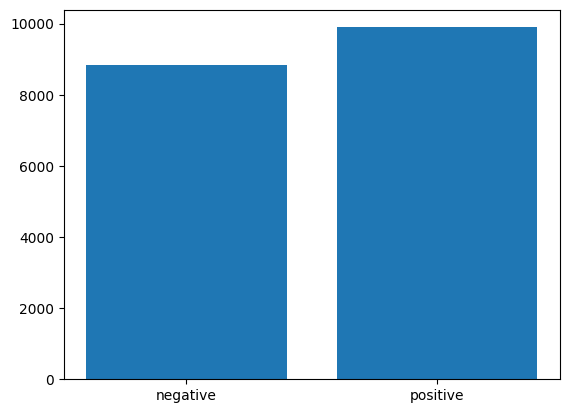

In [5]:
sentiment_count = df.groupby('sentiment').count()
# show number of count of positive and negative
print(sentiment_count)
# Showing the bar plot of positive and negative
plt.bar(sentiment_count.index.values, sentiment_count['tweet_text'])

# Using module to show most used words for pos and neg tweets

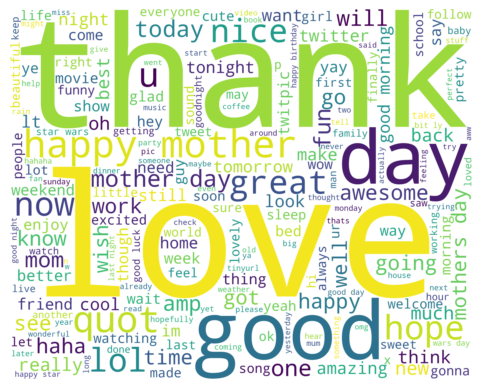

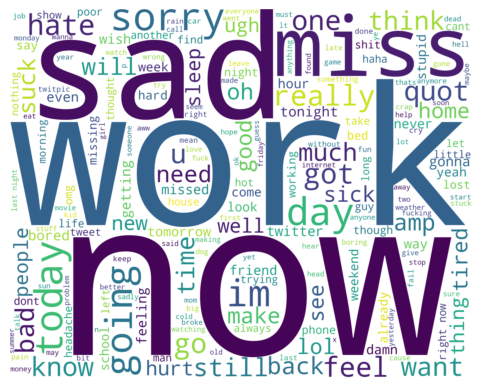

In [6]:
from wordcloud import WordCloud

positive_tweets = df[df['sentiment'] == 'positive']
negative_tweets = df[df['sentiment'] == 'negative']

txt_positive = " ".join(tweet.lower() for tweet in positive_tweets['tweet_text'])
txt_negative = " ".join(tweet.lower() for tweet in negative_tweets['tweet_text'])

# Generate a word cloud image
wordcloud_positive = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_positive)
wordcloud_negative = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_negative)

# Display the generated image:
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.show()

plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.show()



# Text Normalization

In [7]:
import re

In [8]:
# example = "Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!!!!!"

In [9]:
# Remove emojis
import emoji

In [10]:

def convert_emoji_to_text(text):
    text = emoji.demojize(text) # Converting the emoji to their word meaning
    text = text.replace(":"," ") # Replacing the colon symbol with a space
    return text

#print(convert_emoji_to_text(example))


In [11]:
# Remove links
def remove_links(text, replace_with=""):
    text = re.sub('(http|https):\/\/\S+', replace_with, text) # regex to remove any links starting with http or https
    return text
#print (remove_links(example))

In [12]:
# Remove hashtags
def remove_hashtags(text, replace_with=""):
    text = re.sub('#+', replace_with, text) # regex to remove any hashtags
    return text

#print (remove_hashtags(example))

In [13]:
# General cleaning / text normalization

In [14]:
# Making string all lowercase
def lower_case_string(text):
    return text.lower()

#print (lower_case_string(example))

In [15]:
# Removing repeated characters
def remove_letter_repetitions(text):
    return re.sub(r'(.)\1+', r'\1\1', text) # regex to remove repeated chars, firstly matches a char which is repeated more than once, then replaces it with the same char twice

#print (remove_letter_repetitions(example))

# Removing punctuation repetitions
def remove_punctuation_repetitions(text, replace_with=""):
    return re.sub(r'[\?\.\!]+(?=[\?\.\!])', replace_with, text) # regex to remove repeated punctuation, firstly matches a punctuation which is repeated more than once, then replaces it with a single punctuation

#print (remove_punctuation_repetitions(example))

In [16]:
# Working with contractions
# Using a contraction dictionary we can replace contractions with their full form
import contractions

In [17]:
# Replacing contractions with their full form: e.g I'm -> I am
def replace_contractions(text):
    text = contractions.fix(text) # Using built in method from contractions library
    return text

#print(replace_contractions(example))

# Tokenization
- stop words
- punctionation
- numbers

In [18]:
# Using nltk library
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
def tokenize(text):
    tokens = word_tokenize(text)
    return tokens

#print(tokenize(example))

In [20]:
# Using a more complex and complete tokenizer
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
stop_words = set(stopwords.words('english')) # Getting the stop words from nltk
print(stop_words)

{'didn', 'those', "needn't", 'an', 've', 'all', 'any', "isn't", 'or', 'only', 'wasn', 'have', 'what', 'into', 'wouldn', "wouldn't", "doesn't", 'couldn', 'nor', 'they', 'do', 'was', 'had', 'a', 'for', 'can', 'in', 'whom', 'to', 'under', 'shan', 'doesn', 'ain', 'very', 'against', "you'd", 'each', 'am', "you'll", 'our', 'than', 'needn', 'ourselves', 'few', 'such', 'this', 'because', 'is', "should've", 'yourself', 'has', 'other', 'from', 'm', 'theirs', 'during', 'isn', 'then', 'through', "won't", 'won', 'between', 'itself', 'having', 'until', 'where', "aren't", 'll', 'ours', 'after', 'below', 'yourselves', "mustn't", 'now', 'hasn', 'i', 'my', 'weren', 'it', 'how', 'of', 'hers', 'on', 'about', 'haven', 'we', 'just', 'out', 'over', 'so', 'if', "hasn't", 'off', 'both', "weren't", 'when', 'that', 'too', 'yours', 'are', 'and', 'most', 'but', 'were', 'with', "mightn't", "shouldn't", 'their', 'while', 'down', 'further', 'being', 'more', "wasn't", 'doing', 'own', "that'll", 'will', 'been', 'you', 

In [33]:
example = "Tom loved this food and he is not going to the restaurant agian."
# Depending if we want to keep punctuation, alphanumeric characters and stopwords we can use the following function with True or False
def custom_tokenization(text, keep_punctuation = False, keep_alphanum = False, keep_stopwords = False):
    token_list = word_tokenize(text)

    punctuation_chars = "!\"#$%&'()*+, -./:;<=>?@[\]^_`{|}~"

    if not keep_punctuation:
        token_list = [token for token in token_list if token not in punctuation_chars] # Add only if not in the punctuation list
    if not keep_alphanum:
        token_list = [token for token in token_list if token.isalpha()] # Add only if is a letter
    if not keep_stopwords:
        stop_words = set(stopwords.words('english'))
        stop_words.discard('not') # Remove stop words which are relevant for sentiment analysis from the stop words list !NOTE: Can add more words to be excluded
        token_list = [token for token in token_list if token not in stop_words] # Add only if not in the stop words list

    return token_list

#print(custom_tokenization(example, keep_punctuation = False, keep_alphanum = False, keep_stopwords = False))

['Tom', 'loved', 'food', 'not', 'going', 'restaurant', 'agian']


## Stemming

In [23]:
from nltk.stem import PorterStemmer 
from nltk.stem import LancasterStemmer # more agressive stemming
from nltk.stem import SnowballStemmer # better than porter and newer
#NOTE: can look at more stemming algos

In [24]:
porter_stemmer = PorterStemmer()
lancaster_stemmer = LancasterStemmer()
snowball_stemmer = SnowballStemmer('english')


In [25]:
# Function to stem tokens given a stemming algorithm
def stemming_tokens(tokens, stemmer):
    token_list = [stemmer.stem(token) for token in tokens] # Add the new stemmed token to the list
    return token_list

In [26]:
#print(stemming_tokens(tokenize(example), snowball_stemmer))

# Preprocessing text

In [43]:
# Processing the string/text

def process_text(text):
    # Removing links and converting emojis to text
    p_txt = remove_links(text)
    p_txt = convert_emoji_to_text(p_txt)

    # Removing hashtags, making string lowercase, removing repeated characters and punctuation and replacing contractions
    p_txt = remove_hashtags(p_txt)
    p_txt = lower_case_string(p_txt)
    p_txt = remove_letter_repetitions(p_txt)
    p_txt = remove_punctuation_repetitions(p_txt)
    p_txt = replace_contractions(p_txt)
    
    # Tokenizing the string
    #p_txt = tokenize(p_txt)
    p_txt1 = tokenize(p_txt)
    p_txt = custom_tokenization(p_txt)

    print("Tokenize:")
    print(p_txt1)
    print("Custom Tokenize:")
    print(p_txt)

    # Stemming the tokens
    p_txt = stemming_tokens(p_txt, snowball_stemmer)
    return p_txt

example = "Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!!!!!"
#print(process_text(example))
process_text(example)

TypeError: 'module' object is not callable